# Convolutional Neural Network (CNN)
I strongly recommend studying the GitHub repository [readme](https://github.com/mohammadkhoubrou/machine-learning-deep-learning-foundations-from-scratch/tree/main/Deep-Learning-Lab/04-CNN) file for a full description of the algorithm steps, elements, and mathematical foundation.

In this file, I have attemped implementing convolutional neural networks for 2D data such as images from scratch using nothing but NumPy and mathematics.

In [128]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

In [129]:
x = np.array([[1,2,3,4],
             [5,6,7,8],
             [9,10,11,12],
             [13,14,15,16]], dtype=float)
x

array([[ 1.,  2.,  3.,  4.],
       [ 5.,  6.,  7.,  8.],
       [ 9., 10., 11., 12.],
       [13., 14., 15., 16.]])

## Convolution forward pass
The following code goes over the image which is a matrix of shape HxW. It travels through the columns of an entire row before going to the next row. Each selected section of the image is then multiplied by the kernel consisted of n x m parameters. Sum of the element of the output matrix is added to the bias.

In [ ]:
def conv2d(X, k, b = 0.0, stride = 1):
    H, W = X.shape # input size
    kH, kW = k.shape # kernel size
    H_out = (H - kH) // stride + 1 # output hight
    W_out = (W - kW) // stride + 1 # output width

    Z = np.zeros((H_out, W_out))

    for h in range(H_out): # travels through rows
        for w in range(W_out): # travels through columns
            vert_start = h * stride
            vert_end = vert_start + kH

            horiz_start = w * stride
            horiz_end = horiz_start + kW

            a_slice_prev = X[vert_start:vert_end, horiz_start:horiz_end] # selecting a section of the image
            Z[h, w] = np.sum(a_slice_prev * k) + b # dot product of the image and parameters
                                                   # added by the bias
    return Z

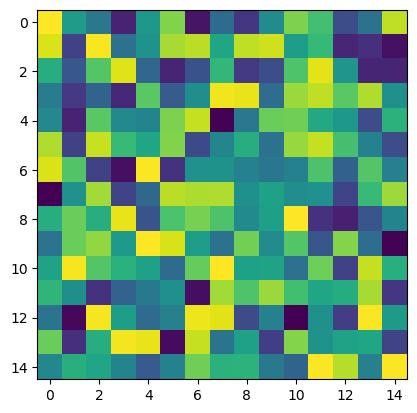

In [131]:
X = np.random.randint(0, 256, (15,15))
plt.imshow(X)

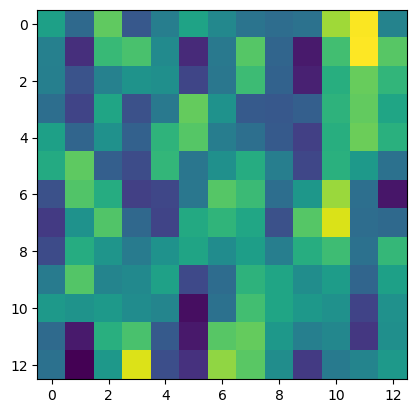

In [132]:
k = np.array([[1, 0, -1],
              [2, 0, -2],
              [1, 0, -1]])
Z = conv2d(X, k, b = 1, stride = 1)
plt.imshow(Z)

The output image after multiple layers of convolution with *Sobel* filter. You can see the image has shrinked after multiple layers of convolution.

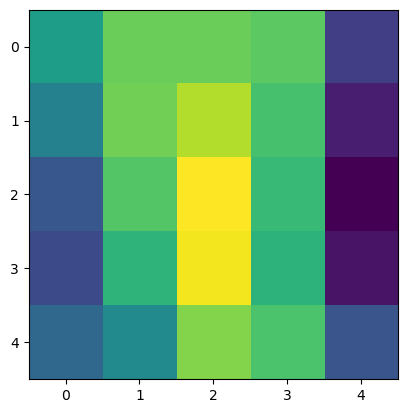

In [133]:
Z = conv2d(Z, k, b = 1, stride = 1)
Z1 = conv2d(Z, k, b = 1, stride = 1)
Z2 = conv2d(Z1, k, b = 1, stride = 1)
Z3 = conv2d(Z2, k, b = 1, stride = 1)
plt.imshow(Z3)

Now, we will upgrade the convolution so that it applies more number of filters instead of one. Most of the function construction is the same except for an extra loop that chooses different filters to be applied.

In [ ]:
def conv2d_multi_layer(X, k, biases, stride=1):
    H, W = X.shape
    filt_count, kH, kW = k.shape

    H_out = (H - kH) // stride + 1
    W_out = (W - kW) // stride + 1

    Z = np.zeros((filt_count, H_out, W_out))

    for f in range(filt_count): # iterates through filters to apply them one at a time

        kernel = k[f]
        bias = biases[f]

        for h in range(H_out):
            for w in range(W_out):
                vert_start = h * stride
                vert_end = vert_start + kH
    
                horiz_start = w * stride
                horiz_end = horiz_start + kW
    
                a_slice_prev = X[vert_start:vert_end, horiz_start:horiz_end]
                Z[f, h, w] = np.sum(a_slice_prev * kernel) + bias
    return Z

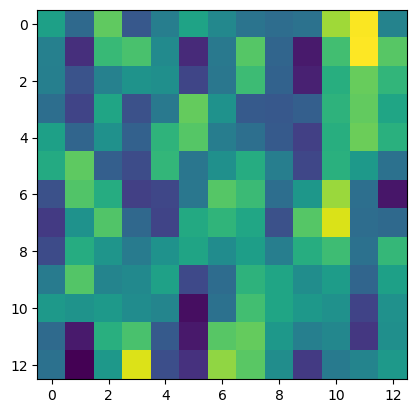

In [135]:
k = np.array([[[1, 0, -1],
              [2, 0, -2],
              [1, 0, -1]],
             [[1, 0, -1],
              [2, 0, -2],
              [1, 0, -1]]], dtype=float)
# b = np.ones((2, X.shape[1] - k.shape[1] +1, X.shape[1] - k.shape[1] +1))
b = np.ones(k.shape[0])
Z = conv2d_multi_layer(X, k, b, stride = 1)
plt.imshow(Z[0])

ReLu is the activation function that returns 0 in case the input is negative and the element itself if it's positive.

Max pooling works almost the same as the convolution. It iterates over different rows and columns to choose a section of the image. Then instead of multiplying the frame by a kernel and adding it to a bias, it chooses the largest pixel value in that frame and returns it. Max pool doesn't have parameters.

In [136]:
def relu(Z):
    return np.maximum(0, Z)

In [ ]:
def maxpool2d(X, pooling_value=2, stride = 2):
    '''
    pooling_value determines how many pixels in the row or the column you're
    in should be selected for comparison and choosing the largest value.
    '''
    m, H, W= X.shape
    H_out = (H - pooling_value) // stride + 1
    W_out = (W - pooling_value) // stride + 1

    P = np.zeros((m, H_out, W_out))

    for c in range(m):
        for h in range(H_out):
            for w in range(W_out):
                vert_start = h * stride
                vert_end = vert_start + pooling_value

                horiz_start = w * stride
                horiz_end = horiz_start + pooling_value

                a_slice_prev = X[
                    c, vert_start:vert_end, horiz_start:horiz_end
                ]
                P[c, h, w] = np.max(a_slice_prev) # returns largest element of the array
    return P

In [ ]:
def flatten(X):
    return X.reshape(-1) #returns a vector of 1xn

Since the softmax function uses Euler's number to the power of z, the result of that could be enormous. Therefore we subtract each element in the array from the maximum value for stability. Exponenial function simply turns the negative value into positive, while preserving their relative difference.

In [ ]:
def dense_forward(x, W, b):
    z = W @ x + b
    return z

def softmax(z): # returns the probability of each prediction being True
    var = z - np.max(z)
    num = np.exp(var)
    return num / np.sum(num)

The cross_entropy function uses logarithm function in it's calculations. Because the log of zero is undefined, we use ```np.clip()``` that check if the elements of an array are in a specific range. Here we have defiend that range *epsilon* that is equal to 0.000000000001 and 0.999999999999. If the value is smaller than the range, it will turn it into epsilon and if it's larger, 1 - epsilon.

In [140]:
def cross_entropy(label, prediction):
    epsilon = 1e-12
    pred = np.clip(
        prediction, epsilon, 1 - epsilon)
    return -np.sum(label * np.log(pred))

## Backpropagation

We begin backpropagation from the last stop in the stream which is cross entropy and softmax.

In [141]:
def softmax_cross_entropy_back(label, prediction):
    return prediction - label

In [142]:
def dense_back(dz, x, W):
    dw = np.outer(dz, x)
    db = dz
    dx = W.T @ dz

    return dw, db, dx

In [ ]:
def flatten_back(output, org_shape): # flatten only needs to go back to the original form
    return output.reshape(org_shape)

Just like the forward pass, we will go through filters, rows, and columns and calculate the derivative of the parameters. Then pass them on to the previous section of the algorithm untill we have found the gradient of the parameters in the filters and biases. Then we apply the gradient descent which multiplies the learning rate by the gradient and subtract it from the old value.

In [144]:
def maxpool_back(dP, A, pool_value = 2, stride = 2):
    filt_count, H, W = A.shape

    dA = np.zeros_like(A)

    H_out, W_out = dP.shape[1:]

    for c in range(filt_count):
        for h in range(H_out):
            for w in range(W_out):
                vert_start = h * stride
                vert_end = vert_start + pool_value
    
                horiz_start = w * stride
                horiz_end = horiz_start + pool_value

                A_slice = A[c, vert_start:vert_end, horiz_start:horiz_end]
                
                max_value = np.max(A_slice)

                mask = (A_slice == max_value)
            
                dA[
                    c,
                    vert_start:vert_end,
                    horiz_start:horiz_end
                ] += mask * dP[c, h, w]
            
    return dA

In [145]:
def relu_back(dA, Z):
    dZ = dA.copy()
    dZ[Z <= 0] = 0

    return dZ

In [146]:
def conv2d_backward(dZ, A, kernels, stride=1):

    filt_count, KH, KW = kernels.shape

    H, W = X.shape

    dX = np.zeros_like(X)

    dK = np.zeros_like(kernels)

    db = np.zeros(filt_count)

    H_out, W_out = dZ.shape[1:]

    for c in range(filt_count):
        k = kernels[c]

        for h in range(H_out):
            for w in range(W_out):

                vert_start = h * stride
                vert_end = vert_start + KH
    
                horiz_start = w * stride
                horiz_end = horiz_start + KW

                A_slice = A[vert_start:vert_end, horiz_start:horiz_end]
                
                gradient = dZ[c, h, w]

                dK[c] += gradient * A_slice

                dX[
                    vert_start:vert_end,
                    horiz_start:horiz_end
                ] += gradient * k

                db[c] += gradient

    return dX, dK, db

In [ ]:
class SimpleCNN:
    '''
    default values are set for the sizes of parameters
    '''

    def __init__(
        self,
        input_size=8,
        num_filters=2,
        kernel_size=3,
        num_classes=3
    ):

        np.random.seed(42)

        self.num_filters = num_filters
        self.kernel_size = kernel_size

        # Convolution parameters
        # Random initialization
        self.kernels = ( 
            np.random.randn(
                num_filters,
                kernel_size,
                kernel_size
            ) * 0.1
        )

        self.conv_biases = np.zeros(num_filters)

        flattened_size = num_filters * 3 * 3

        # Dense parameters
        self.W_dense = (
            np.random.randn(
                num_classes,
                flattened_size
            ) * 0.1
        )

        self.b_dense = np.zeros(num_classes)

    # Forward pass

    def forward(self, X):

        self.X = X

        self.Z_conv = conv2d_multi_layer(
            X,
            self.kernels,
            self.conv_biases
        )

        self.A_relu = relu(
            self.Z_conv
        )

        self.P = maxpool2d(
            self.A_relu
        )

        self.x_flat = flatten(
            self.P
        )

        self.Z_dense = dense_forward(
            self.x_flat,
            self.W_dense,
            self.b_dense
        )

        self.y_pred = softmax(
            self.Z_dense
        )

        return self.y_pred

    # Backpropagation

    def backward(self, y_true):

        # Softmax + Cross Entropy
        dZ_dense = (
            self.y_pred - y_true
        )

        # Dense
        dW_dense, db_dense, dx_flat = dense_back(
            dZ_dense,
            self.x_flat,
            self.W_dense
        )

        # Flatten
        dP = flatten_back(
            dx_flat,
            self.P.shape
        )

        # Max Pool
        dA_relu = maxpool_back(
            dP,
            self.A_relu
        )

        # ReLU
        dZ_conv = relu_back(
            dA_relu,
            self.Z_conv
        )

        # Convolution
        dX, dK, db_conv = conv2d_backward(
            dZ_conv,
            self.X,
            self.kernels
        )

        self.dK = dK
        self.db_conv = db_conv

        self.dW_dense = dW_dense
        self.db_dense = db_dense

    # Parameter update

    def update(self, learning_rate=0.01):

        self.kernels -= (
            learning_rate * self.dK
        )

        self.conv_biases -= (
            learning_rate * self.db_conv
        )

        self.W_dense -= (
            learning_rate * self.dW_dense
        )

        self.b_dense -= (
            learning_rate * self.db_dense
        )

    # Train

    def train(
        self,
        X,
        y,
        epochs=100, # by default 100 times passes through the entire data
        learning_rate=0.01
    ):

        for epoch in range(epochs):

            predictions = self.forward(X)

            loss = cross_entropy(
                y,
                predictions
            )

            self.backward(y)

            self.update(
                learning_rate
            )

            if epoch % 10 == 0:

                print(
                    f"Epoch {epoch:3d} | "
                    f"Loss: {loss:.6f}"
                )
                
        

In [148]:
np.random.seed(1)

X = np.random.randn(8, 8)

y = np.array([1, 0, 0])

model = SimpleCNN(
    input_size=8,
    num_filters=2,
    kernel_size=3,
    num_classes=3
)

model.train(
    X,
    y,
    epochs=100,
    learning_rate=0.01
)

Epoch   0 | Loss: 1.161414
Epoch  10 | Loss: 0.938237
Epoch  20 | Loss: 0.763064
Epoch  30 | Loss: 0.602698
Epoch  40 | Loss: 0.461785
Epoch  50 | Loss: 0.342948
Epoch  60 | Loss: 0.251244
Epoch  70 | Loss: 0.185816
Epoch  80 | Loss: 0.140417
Epoch  90 | Loss: 0.108992
